In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
transform = transforms.ToTensor()
dataset = datasets.MNIST(root = './data',transform = transform , train = True,download = True)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.85MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 156kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.20MB/s]


Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [5]:
dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

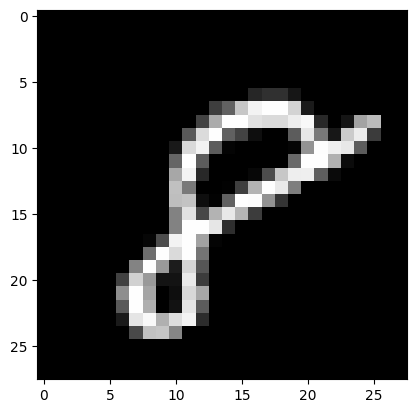

In [24]:

plt.imshow(dataset[59999][0].squeeze().numpy(),cmap = 'gray')
plt.show()

In [25]:
data_loader =DataLoader(dataset = dataset,batch_size = 32,shuffle = True)

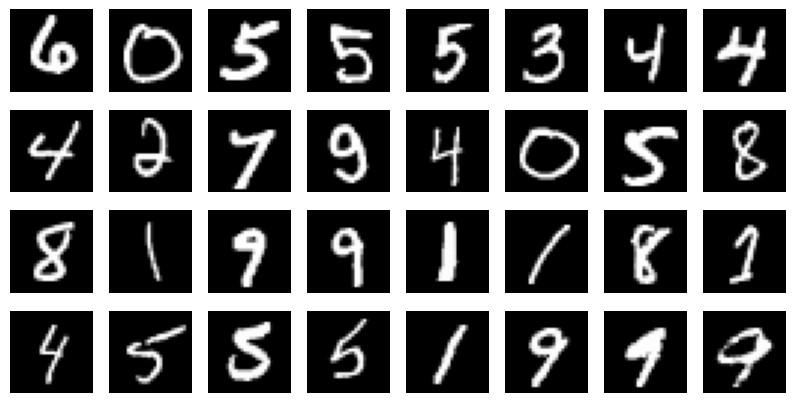

In [37]:
images,labels = next(iter(data_loader))
fig , axes = plt.subplots(4,8,figsize = (10,5))
for i , ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze().numpy(),cmap = 'gray')
    ax.axis('off')
    
plt.show()

In [ ]:
class VAE(nn.Module):
    def __init__(self,latent_dim = 2,height = 28,width = 28):
        super().__init__()
        self.input_dim = height*width
        self.flatten = nn.Flatten()
        self.downsample = nn.Sequential(
            nn.Linear(self.input_dim,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            )
        self.fc_mu = nn.Linear(64,latent_dim)
        self.fc_log_var = nn.Linear(64,latent_dim)
        self.upsample=nn.Sequential(
            nn.Linear(latent_dim,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,784),
            nn.Sigmoid(),
                      )
    def reparameterise(self,mu,std):
        epsilon = torch.randn_like(std)
        q = mu + epsilon*std
        return q
    def forward(self,x):
        z = self.downsample(self.flatten(x))
        mu  = self.fc_mu(z)
        log_var = self.fc_log_var(z)
        std = torch.exp(0.5*log_var)
        q = self.reparameterise(mu,std)
        out = self.upsample(q)
        out = out.view(-1,1,28,28)

        return out,mu,log_var
        
        
    



    
        

        

SyntaxError: expected ':' (3834062934.py, line 29)